# 小组作业

In [1]:
import pandas as pd

# 加载数据
df = pd.read_csv(".\\vehicles.csv",low_memory=False)

# 初步查看数据结构
print(df.shape)
df.head()

(34287, 74)


,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,...,youSaveSpend,guzzler,trans_dscr,tCharger,sCharger,atvType,fuelType2,rangeA,evMotor,mfrCode
0,15.689436,0.0,0.0,0.0,19,0.0,0,0.0,0.0,0.0,...,-1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29.950562,0.0,0.0,0.0,9,0.0,0,0.0,0.0,0.0,...,-11500,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12.195570,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,...,1750,NaN,SIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,29.950562,0.0,0.0,0.0,10,0.0,0,0.0,0.0,0.0,...,-11500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17.337486,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,-3500,NaN,NaN,T,NaN,NaN,NaN,NaN,NaN,NaN


## 第一部分

1、	读取汽车燃料效率数据，理解数据代表的意义。

2、	描述燃料效率数据

a)	多少行列？

b)	包含几年的数据？起始年份是哪一年？展示每年汽车的数量（图）

c)	燃料类型都有哪些（fuelType）？大多数车是哪种类型？展示每种燃料类型汽车的数量（图）

d)	将汽车的传动方式（trany）改为“Auto”和”Manual”。统计不同类型的记录数量。注意缺失值处理。

e)	带或是不带增压充电器（sCharger）的车的数量和年份的关系。展示不同年份带或是不带增压充电器汽车的数量或者百分比用groupbar展示（图）。

f)	把sCharger改为逻辑型变量

### 行数与列数

In [2]:
print(f"数据行数: {df.shape[0]}，列数: {df.shape[1]}")

数据行数: 34287，列数: 74


### 包含数据的年份与每年的数据

年份范围：1984 - 2014


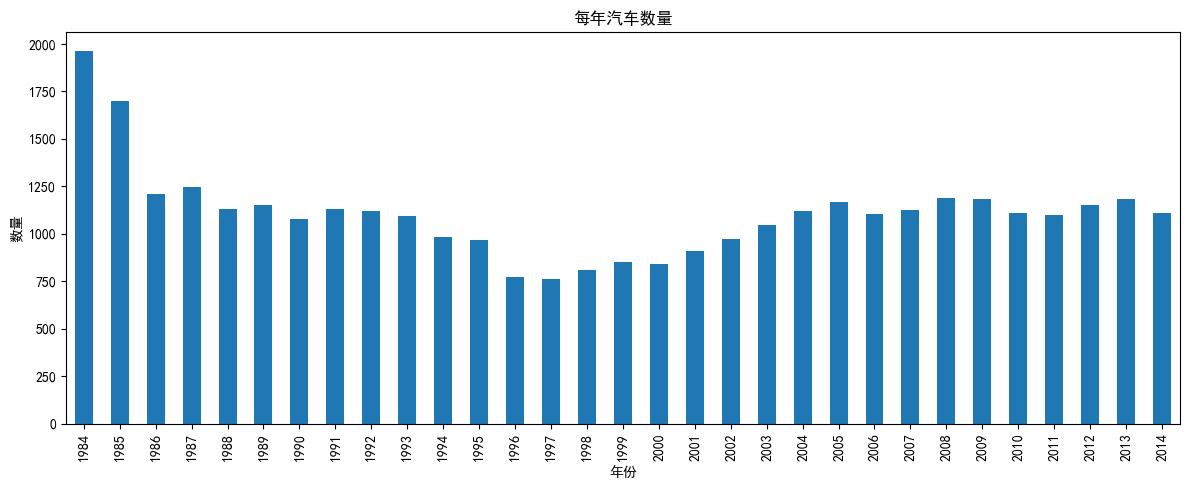

In [4]:
import numpy
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 显示中文
plt.rcParams['axes.unicode_minus'] = False    # 显示负号
print(f"年份范围：{df['year'].min()} - {df['year'].max()}")
year_counts = df['year'].value_counts().sort_index()
year_counts.plot(kind='bar', figsize=(12,5), title="每年汽车数量")
plt.xlabel("年份")
plt.ylabel("数量")
plt.tight_layout()
plt.show()


### 燃料类型

燃料类型统计：
 fuelType
Regular                        23525
Premium                         8433
Gasoline or E85                 1029
Diesel                          1025
Premium or E85                    83
CNG                               57
Electricity                       56
Midgrade                          41
Gasoline or natural gas           18
Gasoline or propane                8
Regular Gas and Electricity        7
Premium Gas or Electricity         5
Name: count, dtype: int64


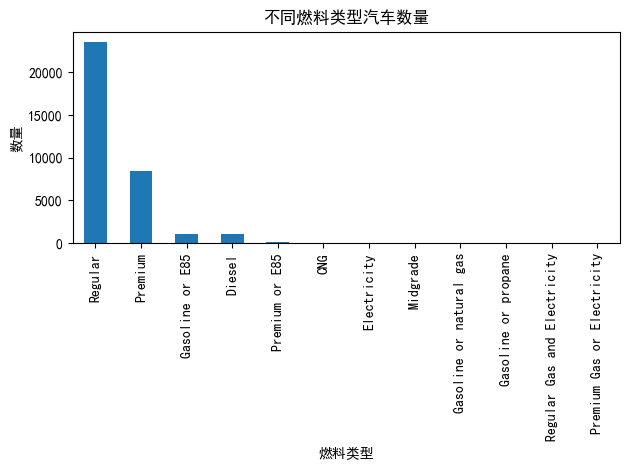

In [5]:
fuel_counts = df['fuelType'].value_counts()
print("燃料类型统计：\n", fuel_counts)

fuel_counts.plot(kind='bar', title="不同燃料类型汽车数量")
plt.xlabel("燃料类型")
plt.ylabel("数量")
plt.tight_layout()
plt.show()


### 汽车传动方式统计

简化传动方式统计：
 trany_simple
Auto       22451
Manual     11825
Unknown       11
Name: count, dtype: int64


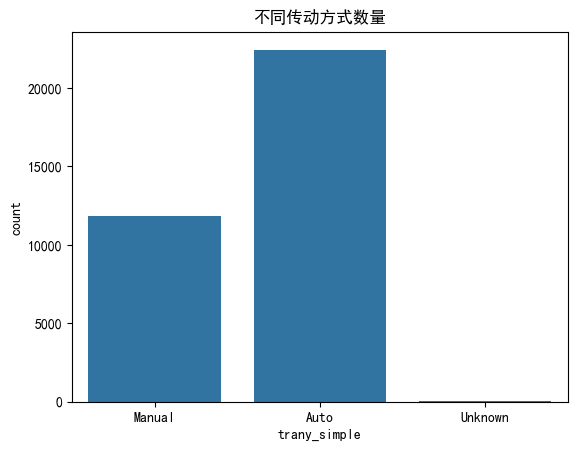

In [8]:
import seaborn as sns
def simplify_trany(val):
    if pd.isna(val):
        return 'Unknown'
    elif 'Auto' in val:
        return 'Auto'
    elif 'Manual' in val:
        return 'Manual'
    return 'Other'

df['trany_simple'] = df['trany'].apply(simplify_trany)
trany_counts = df['trany_simple'].value_counts()
print("简化传动方式统计：\n", trany_counts)

sns.countplot(x='trany_simple', data=df)
plt.title("不同传动方式数量")
plt.show()


### 是否配备增压充电器

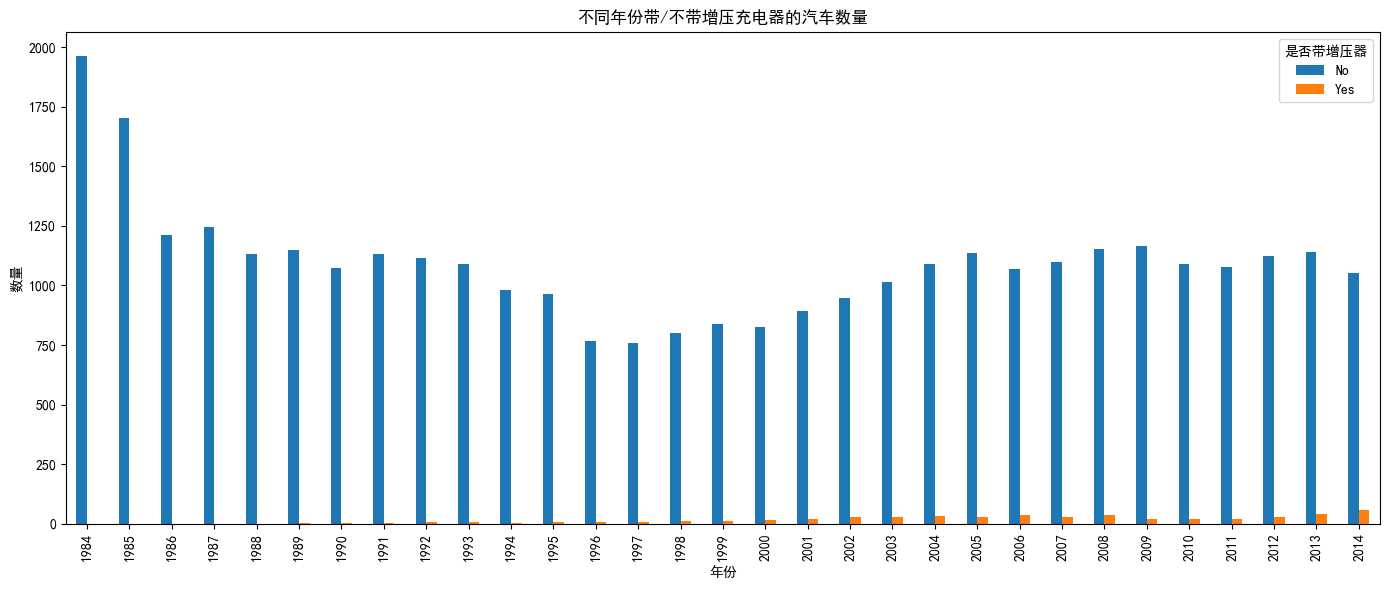

In [9]:
df['sCharger'] = df['sCharger'].fillna('No')
df['sCharger_bin'] = df['sCharger'].apply(lambda x: 'Yes' if x == 'S' else 'No')

charger_counts = df.groupby(['year', 'sCharger_bin']).size().unstack().fillna(0)
charger_counts.plot(kind='bar', stacked=False, figsize=(14,6))
plt.title("不同年份带/不带增压充电器的汽车数量")
plt.xlabel("年份")
plt.ylabel("数量")
plt.legend(title="是否带增压器")
plt.tight_layout()
plt.show()

### sCharger 转换为布尔值

In [20]:
df['sCharger_bool'] = df['sCharger'] == 'S'
df['sCharger_bool']

0        False
1        False
2        False
3        False
4        False
         ...  
34282    False
34283    False
34284    False
34285    False
34286    False
Name: sCharger_bool, Length: 34287, dtype: bool

## 第二部分
1、	按照年份分组，对每个组计算highway,city,和combine的平均燃油效率（comb08，highway08，city08）。保存到一个新的dataframe。

（新的dataframe的列名如下year，avgMPG，avgHghy，avgCity）补充：只研究燃油汽车（gas）

2、	绘制year和avgMPG的散点图。

3、	研究车的马力数（displ）和燃油效率（comb08）之间的关系。散点图展示。

4、	绘制year和马力数（displ）的散点图。

5、	整合每年的平均燃油效率和平均马力数（引擎排量）。绘制共享年份坐标轴的平均燃油效率和平均马力数散点图。

### 分组求平均值，创建新DataFrame

In [21]:
df['fuelType1']

0        Regular Gasoline
1        Regular Gasoline
2        Regular Gasoline
3        Regular Gasoline
4        Premium Gasoline
               ...       
34282    Regular Gasoline
34283    Regular Gasoline
34284    Regular Gasoline
34285    Regular Gasoline
34286    Premium Gasoline
Name: fuelType1, Length: 34287, dtype: object

In [26]:
gas_df = df[df['fuelType1'] == 'Regular Gasoline']  # 只研究燃油汽车

avg_mpg_df = gas_df.groupby('year')[['comb08', 'highway08', 'city08']].mean().reset_index()
avg_mpg_df.columns = ['year', 'avgMPG', 'avgHghy', 'avgCity']
print(avg_mpg_df.head())

   year     avgMPG    avgHghy    avgCity
0  1984  19.121622  22.267333  17.264982
1  1985  19.383495  22.541609  17.484743
2  1986  19.345865  22.473684  17.461466
3  1987  19.189655  22.382033  17.272232
4  1988  19.489447  22.831156  17.501508


### 年份与平均MPG散点图

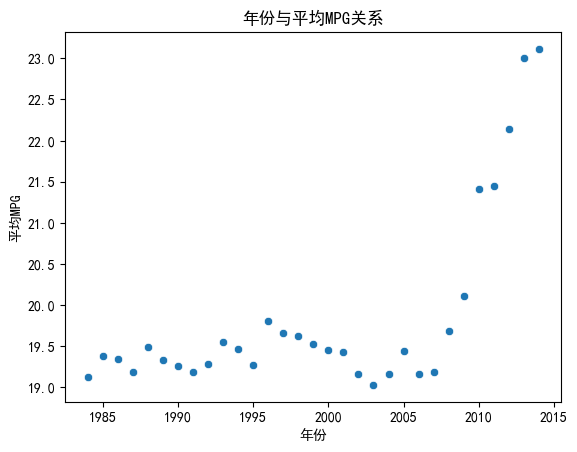

In [27]:
sns.scatterplot(x='year', y='avgMPG', data=avg_mpg_df)
plt.title("年份与平均MPG关系")
plt.xlabel("年份")
plt.ylabel("平均MPG")
plt.show()


### 排量与燃油效率关系

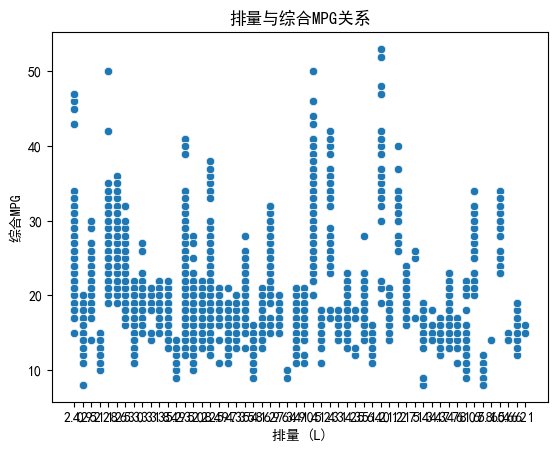

In [28]:
sns.scatterplot(x='displ', y='comb08', data=gas_df)
plt.title("排量与综合MPG关系")
plt.xlabel("排量 (L)")
plt.ylabel("综合MPG")
plt.show()


### 年份与排量关系

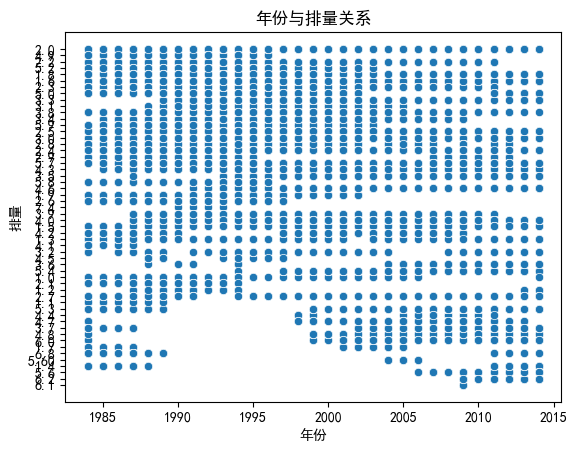

In [29]:
sns.scatterplot(x='year', y='displ', data=gas_df)
plt.title("年份与排量关系")
plt.xlabel("年份")
plt.ylabel("排量")
plt.show()


### 平均MPG与平均排量整合图

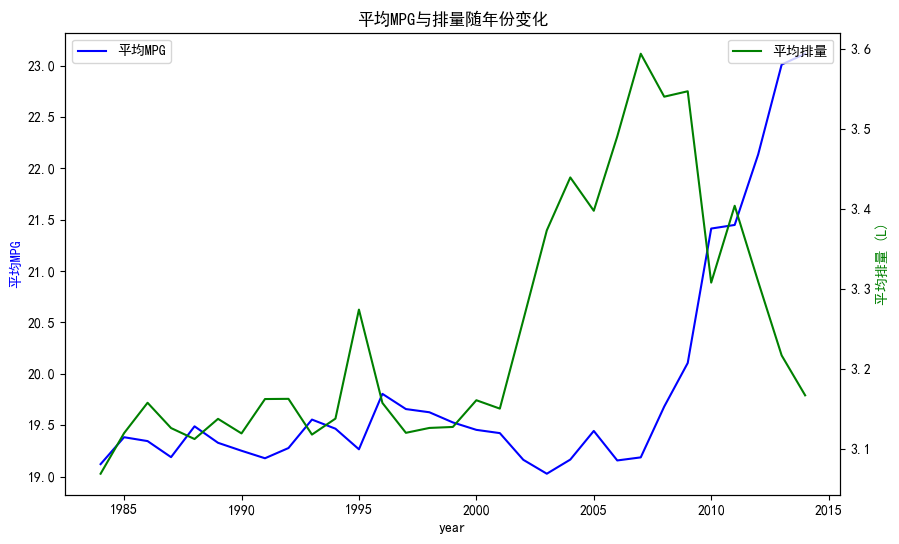

In [34]:
# 尝试将 'displ' 转换为数值，无法转换的将变为 NaN
gas_df.loc[:, 'displ'] = pd.to_numeric(gas_df['displ'], errors='coerce')

# 删除 NaN
gas_df = gas_df.dropna(subset=['displ'])

avg_displ_df = gas_df.groupby('year')['displ'].mean().reset_index()
merged = pd.merge(avg_mpg_df, avg_displ_df, on='year')

fig, ax1 = plt.subplots(figsize=(10,6))
sns.lineplot(x='year', y='avgMPG', data=merged, ax=ax1, color='blue', label='平均MPG')
ax1.set_ylabel("平均MPG", color='blue')
ax2 = ax1.twinx()
sns.lineplot(x='year', y='displ', data=merged, ax=ax2, color='green', label='平均排量')
ax2.set_ylabel("平均排量 (L)", color='green')
plt.title("平均MPG与排量随年份变化")
plt.show()


## 第三部分
1、	哪种气缸数的车的数量最多？cylinders

2、	研究4缸汽车，不同年份生产商的数量（make）


### 气缸数最多的是？


气缸数量统计：
 cylinders
4     12970
6     12019
8      7636
5       755
12      473
3       180
10      137
2        51
-        47
16        7
Name: count, dtype: int64


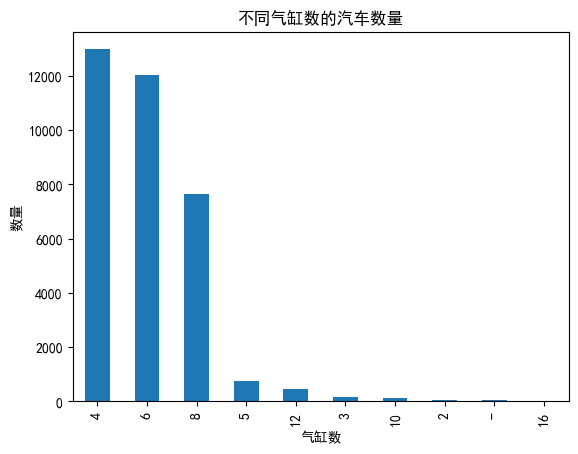

In [35]:
cyl_counts = df['cylinders'].value_counts()
print("气缸数量统计：\n", cyl_counts)
cyl_counts.plot(kind='bar', title="不同气缸数的汽车数量")
plt.xlabel("气缸数")
plt.ylabel("数量")
plt.show()


In [45]:
print(df['cylinders'].value_counts())
df[df['cylinders']==4]

cylinders
4     12970
6     12019
8      7636
5       755
12      473
3       180
10      137
2        51
-        47
16        7
Name: count, dtype: int64


,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,...,tCharger,sCharger,atvType,fuelType2,rangeA,evMotor,mfrCode,trany_simple,sCharger_bin,sCharger_bool


### 4缸车的制造商（按年份）

['4' '12' '8' '6' '5' '10' '2' '3' nan '16' '-']
object
       barrels08  barrelsA08  charge120  charge240  city08  city08U  cityA08  \
0      15.689436         0.0        0.0        0.0      19      0.0        0   
2      12.195570         0.0        0.0        0.0      23      0.0        0   
4      17.337486         0.0        0.0        0.0      17      0.0        0   
5      14.964294         0.0        0.0        0.0      21      0.0        0   
6      13.184400         0.0        0.0        0.0      22      0.0        0   
...          ...         ...        ...        ...     ...      ...      ...   
34282  14.964294         0.0        0.0        0.0      19      0.0        0   
34283  14.327048         0.0        0.0        0.0      20      0.0        0   
34284  15.689436         0.0        0.0        0.0      18      0.0        0   
34285  15.689436         0.0        0.0        0.0      18      0.0        0   
34286  18.304342         0.0        0.0        0.0      16      

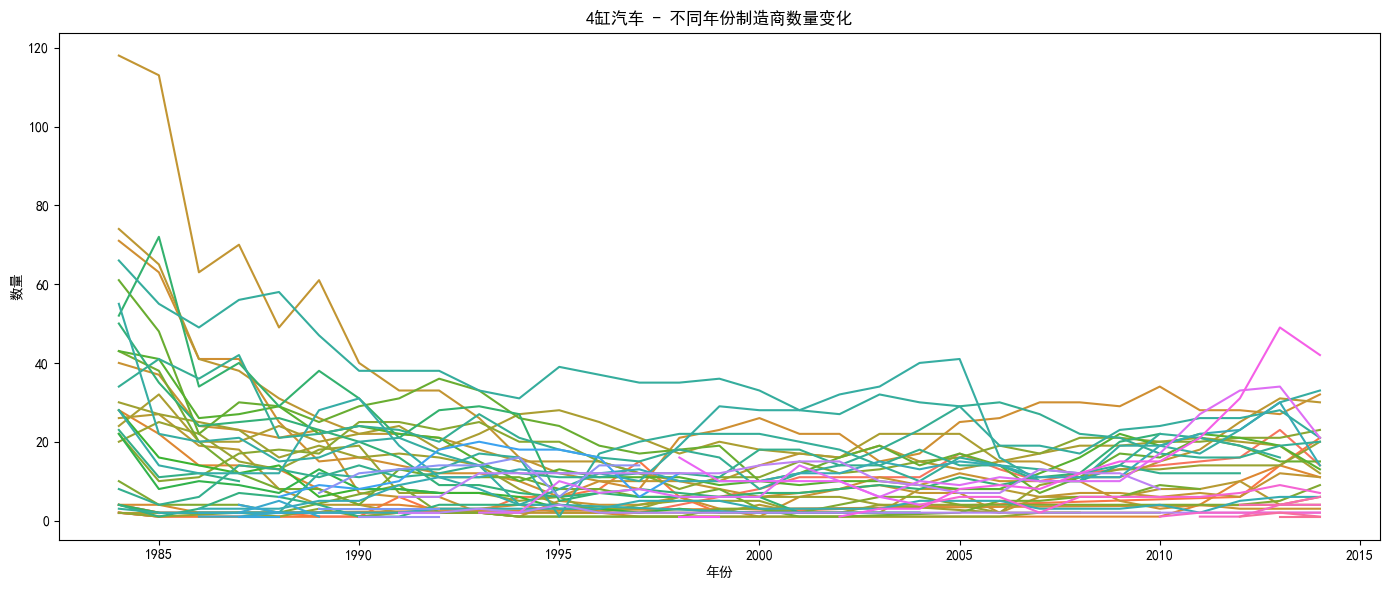

In [49]:
df['cylinders_num'] = pd.to_numeric(df['cylinders'], errors='coerce')
df_4cyl = df[df['cylinders_num'] == 4]
print(df['cylinders'].unique())
print(df['cylinders'].dtype)
print(df_4cyl)
make_counts = df_4cyl.groupby(['year', 'make']).size().reset_index(name='count')

plt.figure(figsize=(14,6))
sns.lineplot(data=make_counts, x='year', y='count', hue='make', legend=False)
plt.title("4缸汽车 - 不同年份制造商数量变化")
plt.xlabel("年份")
plt.ylabel("数量")
plt.tight_layout()
plt.show()
